In [1]:
import numpy as np 
import pandas as pd 
import random 
random.seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.shape

(200, 5)

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

feature_cols = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[feature_cols]

In [5]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

In [7]:
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, feature_cols),

],remainder="drop")


model = Pipeline(steps=[
    ("process" , preprocessor), 
    ("model", KMeans(n_clusters=5, random_state=42, n_init=10))
    ])

In [8]:
clusters = model.fit_predict(X)
df["Cluster"] = clusters

In [9]:
clusters

array([3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 2, 3, 4, 3, 2, 3, 4, 3, 3, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 4, 3, 4, 3, 2, 3, 2, 3, 2, 3, 2, 3, 4, 3,
       2, 3, 2, 3, 3, 3, 2, 3, 3, 4, 2, 4, 2, 4, 3, 4, 4, 3, 2, 2, 4, 3,
       2, 2, 3, 3, 4, 2, 2, 2, 4, 3, 2, 4, 3, 2, 4, 4, 4, 2, 3, 4, 2, 3,
       3, 2, 2, 3, 4, 2, 2, 3, 2, 3, 4, 3, 3, 2, 4, 3, 4, 3, 2, 4, 4, 4,
       4, 3, 2, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 0, 1, 0, 4, 0, 4, 0, 4, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       4, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

C:\Users\Vague\AppData\Local\Temp\ipykernel_17320\2775287101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")


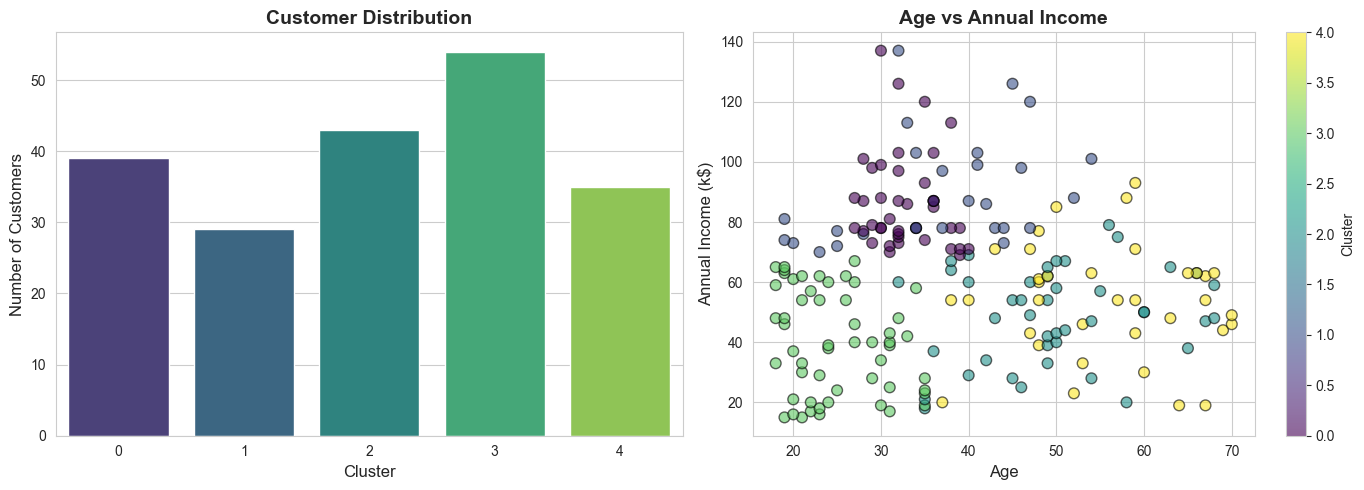

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 5))

# 1. Cluster distribution
plt.subplot(1, 2, 1)
cluster_counts = df["Cluster"].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.title("Customer Distribution", fontsize=14, fontweight="bold")

# 2. Age vs Annual Income
plt.subplot(1, 2, 2)
scatter = plt.scatter(df["Age"], df["Annual Income (k$)"], c=df["Cluster"], cmap="viridis", alpha=0.6, edgecolors='k', s=60)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Annual Income (k$)", fontsize=12)
plt.title("Age vs Annual Income", fontsize=14, fontweight="bold")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()